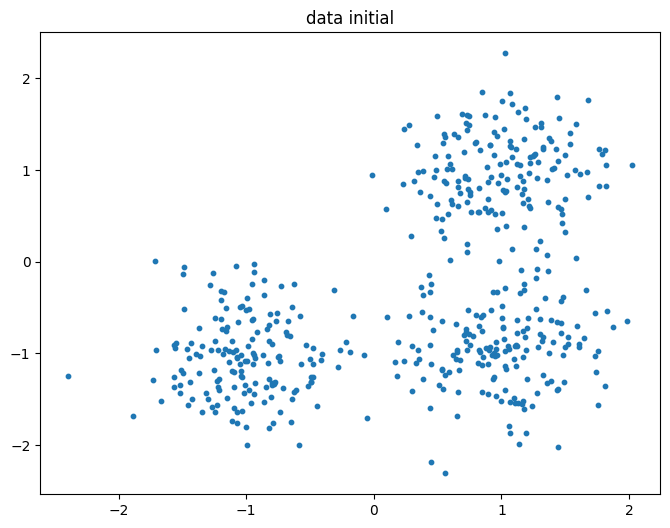

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import MeanShift, estimate_bandwidth
from sklearn.datasets import make_blobs

centers = [[1, 1], [-1, -1], [1, -1]]
X, _= make_blobs(n_samples=500, centers=centers, cluster_std=0.4)

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], s=10)
plt.title('data initial')
plt.show()

In [7]:
bandwidth=estimate_bandwidth(X, quantile=0.2, n_samples=500)
print(f"La valeur de sigma est estimee a: {bandwidth:.3f}")

ms = MeanShift(bandwidth=bandwidth, bin_seeding=True)
ms.fit(X)

labels=ms.labels_
cluster_centers = ms.cluster_centers_ # les attracteurs de densite
n_clusters_ = len(np.unique(labels))

print(f"Le nombre de cluster est: {n_clusters_}")

La valeur de sigma est estimee a: 0.784
Le nombre de cluster est: 3


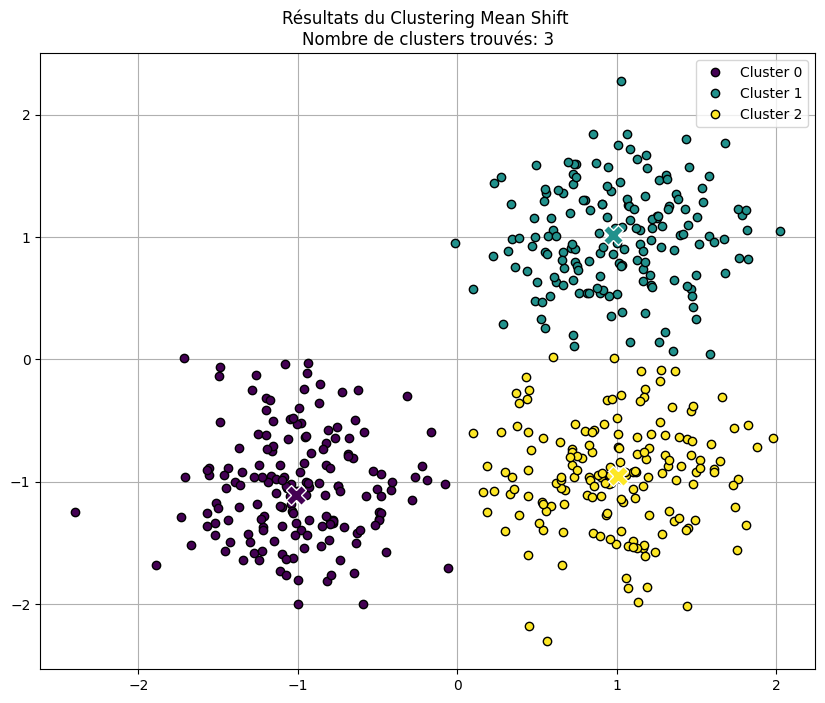

In [14]:
plt.figure(figsize=(10,8))

colors=plt.cm.viridis(np.linspace(0, 1, n_clusters_))
for k,col in zip(range(n_clusters_), colors):
    members=(labels == k)

    cluster_center = cluster_centers[k]
    plt.plot(X[members, 0], X[members, 1], 'o', markerfacecolor=col, markeredgecolor='k', markersize=6, label=f'Cluster {k}')
    
    # Afficher le centre du cluster (l'attracteur)
    plt.plot(cluster_center[0], cluster_center[1], 'X', markerfacecolor=col, markeredgecolor='w', markersize=14)

plt.title(f'Résultats du Clustering Mean Shift \nNombre de clusters trouvés: {n_clusters_}')
plt.legend()
plt.grid(True)
plt.show()

# L'algo Shared Nearest Neighbor Similarity based clustering

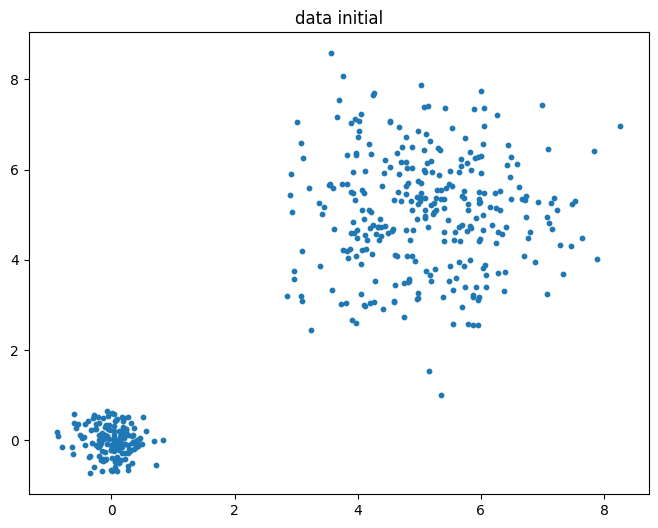

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN

# Un cluster dense et un cluster diffus
X1, _ = make_blobs(n_samples=150, centers=[(0, 0)], cluster_std=0.3)
X2, _ = make_blobs(n_samples=300, centers=[(5, 5)], cluster_std=1.2)
X = np.vstack([X1, X2])

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], s=10)
plt.title("data initial")
plt.show()



In [17]:
k = 20           # Nombre de voisins
min_similarity = 5 # min 5 voisins pour etre similaire

# Trouver les k plus proches voisins pour chaque point
print(f"Calcul des {k} plus proches voisins...")
knn = NearestNeighbors(n_neighbors=k)
knn.fit(X)
distances, knn_graph = knn.kneighbors(X, return_distance=True)

# la matrice de similarité SNN
n_samples = X.shape[0]
snn_similarity_matrix = np.zeros((n_samples, n_samples))

print("Construction de la matrice de similarité SNN...")
for i in range(n_samples):
    for j in range(i + 1, n_samples):
        # Calculer le nombre de voisins en commun
        shared_neighbors = len(np.intersect1d(knn_graph[i], knn_graph[j]))
        
        # Condition: les deux points doivent être dans leurs voisinages respectifs
        is_i_neighbor_of_j = i in knn_graph[j]
        is_j_neighbor_of_i = j in knn_graph[i]
        
        if is_i_neighbor_of_j and is_j_neighbor_of_i:
            snn_similarity_matrix[i, j] = shared_neighbors
            snn_similarity_matrix[j, i] = shared_neighbors

# On peut utiliser cette matrice comme une "distance" inversée pour DBSCAN
# DBSCAN travaille avec des distances, donc on va utiliser 1 / (1 + similarité)
# Plus la similarité est haute, plus cette "distance" est faible.
snn_distance_matrix = 1 / (1 + snn_similarity_matrix)
# Remplacer les infinis (similarité de 0) par une grande distance
snn_distance_matrix[snn_distance_matrix == 1] = 1000 




Calcul des 20 plus proches voisins...
Construction de la matrice de similarité SNN...


In [ ]:
# --- 3. Phase 2: Clustering avec DBSCAN sur la nouvelle métrique ---

# DBSCAN va maintenant travailler sur notre matrice de "distance SNN".
print("Application de DBSCAN sur la matrice de distance SNN...")

# Les paramètres Eps et MinPts sont maintenant dans l'espace de la "similarité"
# Eps: distance SNN maximale pour être considéré comme voisin. 
# Si on veut au moins 7 voisins partagés (min_similarity), la distance est 1/(1+7) = 0.125
eps_snn = 0.125 
min_pts_snn = 5

# On utilise metric='precomputed' pour dire à DBSCAN d'utiliser notre matrice
dbscan_snn = DBSCAN(eps=eps_snn, min_samples=min_pts_snn, metric='precomputed')
labels = dbscan_snn.fit_predict(snn_distance_matrix)

# --- 4. Visualisation ---
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
print(f"\nNombre de clusters trouvés : {n_clusters_}")

plt.figure(figsize=(10, 8))
unique_labels = set(labels)
colors = plt.cm.viridis(np.linspace(0, 1, len(unique_labels)))

for k, col in zip(unique_labels, colors):
    if k == -1:
        col = 'gray' # Couleur pour le bruit
        label = 'Bruit'
    else:
        label = f'Cluster {k}'
        
    class_member_mask = (labels == k)
    xy = X[class_member_mask]
    plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=col, markeredgecolor='k', markersize=6, label=label)

plt.title(f'Résultats du Clustering SNN\nNombre de clusters trouvés: {n_clusters_}')
plt.legend()
plt.grid(True)
plt.show()